<a href="https://colab.research.google.com/github/dhrubajyotideb/YT_cmnts_SentimentAnalysis/blob/main/YT_BERT_ML1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install transformers datasets sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch

In [7]:
df = pd.read_csv("/content/YoutubeCommentsDataSet.csv")
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [8]:
df.columns

Index(['Comment', 'Sentiment'], dtype='object')

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df['Sentiment'].unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [11]:
df['Sentiment'] = df['Sentiment'].map({
    'negative': 0,
    'neutral': 1,
    'positive': 2
})

In [12]:
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,1
1,here in nz 50 of retailers don’t even have con...,0
2,i will forever acknowledge this channel with t...,2
3,whenever i go to a place that doesn’t take app...,0
4,apple pay is so convenient secure and easy to ...,2


In [13]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Comment'],
    df['Sentiment'],
    test_size=0.2,
    random_state=42
)

In [14]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

from datasets import Dataset

import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = df[['Comment', 'Sentiment']]

df.dropna(inplace=True)

df['Comment'] = df['Comment'].astype(str)

In [17]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Comment'],
    df['Sentiment'],
    test_size=0.2,
    random_state=42
)

In [18]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True
)

In [19]:
df['Comment'].isnull().sum()

np.int64(0)

In [20]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels.tolist()
})

In [21]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='weighted'
    )

    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [23]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 39.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [24]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8
)

In [25]:
import transformers
print(transformers.__version__)

5.0.0


In [26]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [28]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.469761,0.478509,0.830656,0.832553,0.830656,0.823107
2,0.264292,0.509369,0.856521,0.855539,0.856521,0.855946


TrainOutput(global_step=3674, training_loss=0.37941223210982156, metrics={'train_runtime': 1562.9416, 'train_samples_per_second': 18.799, 'train_steps_per_second': 2.351, 'total_flos': 3892226518407168.0, 'train_loss': 0.37941223210982156, 'epoch': 2.0})

In [30]:
trainer.evaluate()

{'eval_loss': 0.5093686580657959,
 'eval_accuracy': 0.8565205554043016,
 'eval_precision': 0.8555392000637899,
 'eval_recall': 0.8565205554043016,
 'eval_f1': 0.8559461794688431,
 'eval_runtime': 59.5028,
 'eval_samples_per_second': 61.728,
 'eval_steps_per_second': 7.731,
 'epoch': 2.0}

In [31]:
predictions = trainer.predict(test_dataset)

In [32]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

cm

array([[ 317,   91,   33],
       [  73,  679,  160],
       [  27,  143, 2150]])

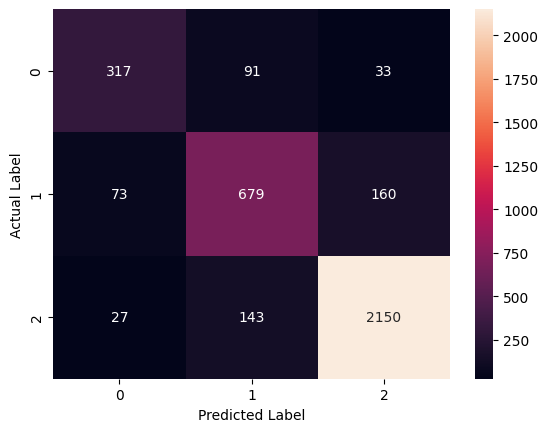

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [35]:
comment = "This video is amazing!"

In [36]:
inputs = tokenizer(comment, return_tensors="pt", truncation=True, padding=True)

In [38]:
import torch

comment = "This video is amazing!"

inputs = tokenizer(
    comment,
    return_tensors="pt",
    truncation=True,
    padding=True
)

# move inputs to same device as model
inputs = {key: value.to(model.device) for key, value in inputs.items()}

outputs = model(**inputs)

prediction = outputs.logits.argmax().item()

prediction

2

In [39]:
labels = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

labels[prediction]

'Positive'